In [7]:
from scipy.special import erfc
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from sionna.phy.fec.ldpc import LDPC5GEncoder, LDPC5GDecoder

def encdoe(msg:list|np.ndarray, codeword_length):
    K = len(msg)
    encoder = LDPC5GEncoder(K ,codeword_length)
    msg = tf.constant(msg, dtype=tf.float32)[None, :]
    codeword = encoder.call(msg)
    return codeword.numpy().ravel().astype(np.int8)

def decode(codeword_llr:list|np.ndarray , msg_length):
    N_LDPC = len(codeword_llr)
    encoder = LDPC5GEncoder(msg_length ,N_LDPC)
    decoder = LDPC5GDecoder(encoder=encoder,num_iter=20)
    llr = tf.constant(codeword_llr, dtype=tf.float32)
    
    decoded = decoder.call(llr)

    return decoded.numpy().astype(np.int8)



R = 1/2
msg_len = 256
msg = np.random.randint(0,2, int(np.round(msg_len/R)))

codeword  = encdoe(msg, 2000)

llr = [10 if i else -10 for i in codeword]

decoded = decode(llr, len(msg))

print(msg.tolist()==decoded.tolist())




True


In [11]:
R = 1/2
msg_len = 256
BER = np.linspace(0.01,.1,10)
repeat_per_ber = 10

BLER_LDPC = []

for p in BER:
    bler = 0
    for i in range(repeat_per_ber):
        msg= np.random.randint(0,2,msg_len)
        encoded = encdoe(msg, int(np.round(len(msg)/R)))
        
        # Make sure encoded is a NumPy integer array
        encoded_np = np.array(encoded, dtype=np.uint8)
        # Generate binary noise based on bit-flip probability p
        noise = (np.random.rand(len(encoded_np)) < p).astype(np.uint8)
        # Induce bit errors
        received = np.bitwise_xor(encoded_np, noise)


        llr = [10 if i else -10 for i in received]


        decoded = decode(llr, msg_len)
        if decoded.tolist() != msg.tolist():
            bler +=1
    print(p, bler/repeat_per_ber)
    BLER_LDPC.append(bler/repeat_per_ber)

BLER_LDPC = np.array(BLER_LDPC)
BLER_LDPC.tofile("BLER_LDPC.csv", sep=',')




0.01 0.0
0.020000000000000004 0.0
0.030000000000000006 0.0
0.04000000000000001 0.0
0.05000000000000001 0.0
0.06000000000000001 0.0
0.07 0.3
0.08 0.6
0.09000000000000001 0.9
0.1 1.0


In [12]:
# Define Q-function
def qfunc(x):
    return 0.5 * erfc(x / np.sqrt(2))
# Error rate function
def error_rate(l, R, p):

    # Avoid log(0) issues by adding a very small number when needed.
    p = np.where(p == 0, 1e-19, p)
    one_minus_p = 1 - p
    C = 1 + p * np.log2(p) + one_minus_p * np.log2(one_minus_p)
    denom = np.log2(one_minus_p / p)
    term = np.sqrt(l / (p * one_minus_p)) * ((C - R) / denom)
    return qfunc(term)


BLER_Q = []

for p in BER:
    bler = error_rate(msg_len/R, R, p)
    
    BLER_Q.append(bler)

BLER_Q = np.array(BLER_Q)
BLER_Q.tofile("BLER_Q.csv", sep=',')




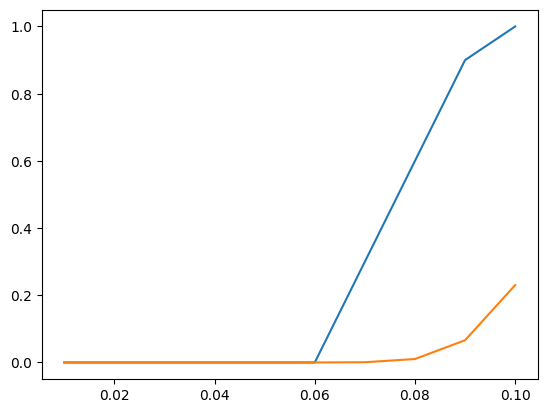

In [13]:
plt.plot(BER,BLER_LDPC)
plt.plot(BER,BLER_Q)